<a href="https://colab.research.google.com/github/mudassar2224/AI-HD-Image-Enhancer-Real-ESRGAN_x4plus/blob/main/AI_HD_Image_Enhancer_%E2%80%94_Real_ESRGAN_x4plus_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 2: Check GPU / CUDA / PyTorch Environment
# ============================================================

import subprocess
import sys

def check_environment() -> dict:
    """
    Checks and prints GPU availability, CUDA version, and PyTorch version.
    Returns a dict with device info for later use.
    """
    info = {}

    # --- PyTorch version ---
    try:
        import torch
        info["torch_version"] = torch.__version__
        print(f"✅ PyTorch Version  : {torch.__version__}")
    except ImportError:
        info["torch_version"] = "Not installed"
        print("⚠️  PyTorch is not installed yet. Will be installed in Cell 3.")

    # --- CUDA / GPU check ---
    try:
        import torch
        if torch.cuda.is_available():
            gpu_name = torch.cuda.get_device_name(0)
            cuda_version = torch.version.cuda
            info["device"] = "cuda"
            info["gpu_name"] = gpu_name
            info["cuda_version"] = cuda_version
            print(f"✅ GPU Available    : Yes")
            print(f"✅ GPU Name         : {gpu_name}")
            print(f"✅ CUDA Version     : {cuda_version}")
        else:
            info["device"] = "cpu"
            info["gpu_name"] = "N/A"
            info["cuda_version"] = "N/A"
            print("⚠️  GPU NOT available. The model will run on CPU.")
            print("    Enhancement will work but will be significantly slower.")
            print("    ➡️  Go to Runtime > Change Runtime Type > GPU to enable GPU.")
    except Exception as e:
        info["device"] = "cpu"
        print(f"⚠️  Could not detect GPU: {e}")

    return info

env_info = check_environment()

✅ PyTorch Version  : 2.11.0+cu128
✅ GPU Available    : Yes
✅ GPU Name         : Tesla T4
✅ CUDA Version     : 12.8


In [2]:
import subprocess, sys

def run_install(cmd: str):
    """Runs a pip install command and prints output."""
    print(f"📦 Running: {cmd}")
    result = subprocess.run(
        cmd, shell=True, capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"⚠️  Warning during install:\n{result.stderr[-500:]}")
    else:
        print("    ✅ Done.")

# Core scientific packages (usually pre-installed on Colab but we pin them)
run_install("pip install -q numpy Pillow opencv-python-headless")

# PyTorch (Colab usually has this; skip if already present)
# The previous command might have installed an incompatible torchvision for cu118.
# We upgrade torchvision to ensure compatibility with the existing torch 2.11.0+cu128.
run_install("pip install -q --upgrade torchvision")

# Real-ESRGAN and its dependency chain
run_install("pip install -q basicsr")
run_install("pip install -q facexlib")
run_install("pip install -q gfpgan")
run_install("pip install -q realesrgan")

# gdown for downloading from Google Drive if needed
run_install("pip install -q gdown")

# scikit-image for PSNR/SSIM metrics (bonus section)
run_install("pip install -q scikit-image")

print("\n✅ All dependencies installed successfully!")

📦 Running: pip install -q numpy Pillow opencv-python-headless
    ✅ Done.
📦 Running: pip install -q --upgrade torchvision
    ✅ Done.
📦 Running: pip install -q basicsr
    ✅ Done.
📦 Running: pip install -q facexlib
    ✅ Done.
📦 Running: pip install -q gfpgan
    ✅ Done.
📦 Running: pip install -q realesrgan
    ✅ Done.
📦 Running: pip install -q gdown
    ✅ Done.
📦 Running: pip install -q scikit-image
    ✅ Done.

✅ All dependencies installed successfully!


In [3]:
# ============================================================
# CELL 4: Clone the Official Real-ESRGAN GitHub Repository
# ============================================================
# We use the official repo for access to inference scripts,
# model architecture definitions, and pretrained weight configs.

import os
from pathlib import Path

REPO_DIR = Path("/content/Real-ESRGAN")

if not REPO_DIR.exists():
    print("📥 Cloning Real-ESRGAN repository...")
    os.system("git clone https://github.com/xinntao/Real-ESRGAN.git /content/Real-ESRGAN")
    print("✅ Repository cloned.")
else:
    print("✅ Repository already exists. Skipping clone.")

# Change working directory to the repo root
os.chdir(REPO_DIR)
print(f"📁 Working directory set to: {os.getcwd()}")

# Install the repo in editable/dev mode so Python can find its modules
os.system("pip install -q -e .")
print("✅ Real-ESRGAN repo installed in dev mode.")

📥 Cloning Real-ESRGAN repository...
✅ Repository cloned.
📁 Working directory set to: /content/Real-ESRGAN
✅ Real-ESRGAN repo installed in dev mode.


In [4]:
# ============================================================
# CELL 5: Download Official RealESRGAN_x4plus Pretrained Weights
# ============================================================
# Official weights from the Real-ESRGAN GitHub releases.
# We skip the download if the file already exists.

import os
from pathlib import Path

# The official weights directory inside the cloned repo
WEIGHTS_DIR = Path("/content/Real-ESRGAN/weights")
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILENAME = "RealESRGAN_x4plus.pth"
MODEL_PATH = WEIGHTS_DIR / MODEL_FILENAME

# Official download URL from GitHub releases
OFFICIAL_URL = (
    "https://github.com/xinntao/Real-ESRGAN/releases/download/"
    "v0.1.0/RealESRGAN_x4plus.pth"
)

if MODEL_PATH.exists():
    size_mb = MODEL_PATH.stat().st_size / (1024 * 1024)
    print(f"✅ Model already downloaded: {MODEL_PATH}")
    print(f"   File size: {size_mb:.1f} MB")
else:
    print(f"📥 Downloading {MODEL_FILENAME} (~67 MB)...")
    exit_code = os.system(f"wget -q --show-progress -O '{MODEL_PATH}' '{OFFICIAL_URL}'")
    if exit_code == 0 and MODEL_PATH.exists():
        size_mb = MODEL_PATH.stat().st_size / (1024 * 1024)
        print(f"✅ Download complete! File size: {size_mb:.1f} MB")
    else:
        print("❌ Download failed. Trying with curl...")
        os.system(f"curl -L -o '{MODEL_PATH}' '{OFFICIAL_URL}'")
        if MODEL_PATH.exists():
            print("✅ Downloaded via curl.")
        else:
            raise FileNotFoundError(
                "❌ Could not download model weights. "
                "Please check your internet connection."
            )

📥 Downloading RealESRGAN_x4plus.pth (~67 MB)...
✅ Download complete! File size: 63.9 MB


In [7]:
!pip install --force-reinstall torch==2.1.2 torchvision==0.16.2 --extra-index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121
ERROR: Could not find a version that satisfies the requirement torch==2.1.2 (from versions: 2.2.0, 2.2.0+cu121, 2.2.1, 2.2.1+cu121, 2.2.2, 2.2.2+cu121, 2.3.0, 2.3.0+cu121, 2.3.1, 2.3.1+cu121, 2.4.0, 2.4.0+cu121, 2.4.1, 2.4.1+cu121, 2.5.0, 2.5.0+cu121, 2.5.1, 2.5.1+cu121, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0, 2.12.0, 2.12.1)
ERROR: No matching distribution found for torch==2.1.2


In [1]:
import sys
import torchvision

# Create a dummy module alignment to fix the basicsr bug
try:
    import torchvision.transforms.functional_tensor
except ImportError:
    # Route the missing module path to the standard functional module
    import torchvision.transforms.functional as F
    sys.modules['torchvision.transforms.functional_tensor'] = F
    print("✅ Successfully patched torchvision for basicsr!")

✅ Successfully patched torchvision for basicsr!


In [2]:
# ============================================================
# CELL 6: Import All Required Libraries
# ============================================================

# --- Standard library ---
import os
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")  # Suppress non-critical warnings

# --- Numerical / Image processing ---
import numpy as np
from PIL import Image
import cv2

# --- PyTorch ---
import torch
import torchvision

# --- Real-ESRGAN official modules ---
# These come from the cloned repo installed in Cell 4
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

# --- Image quality metrics ---
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# --- Google Colab utilities ---
from google.colab import files
from IPython.display import display, Image as IPImage, HTML
import ipywidgets as widgets

print("✅ All libraries imported successfully!")
print(f"   PyTorch  : {torch.__version__}")
print(f"   OpenCV   : {cv2.__version__}")
print(f"   NumPy    : {np.__version__}")

✅ All libraries imported successfully!
   PyTorch  : 2.12.1+cu130
   OpenCV   : 4.13.0
   NumPy    : 2.0.2


In [3]:
# ============================================================
# CELL 7: Global Configuration & Folder Structure
# ============================================================
# All settings are stored here so you only need to change one place.

from pathlib import Path

# ---- Project Paths ----
BASE_DIR       = Path("/content/Real-ESRGAN")
INPUT_FOLDER   = BASE_DIR / "input"
OUTPUT_FOLDER  = BASE_DIR / "output"
WEIGHTS_FOLDER = BASE_DIR / "weights"

# ---- Model Configuration ----
MODEL_NAME     = "RealESRGAN_x4plus"
MODEL_PATH     = WEIGHTS_FOLDER / "RealESRGAN_x4plus.pth"
UPSCALE_FACTOR = 4          # Use 4 for x4 upscaling (recommended)
TILE_SIZE      = 0          # 0 = no tiling (use 400 if GPU OOM errors occur)
TILE_PAD       = 10         # Padding between tiles (relevant only if tiling)
PRE_PAD        = 0          # Pre-padding for edge artifacts
HALF_PRECISION = False      # Set True only on newer GPUs (may cause issues on T4)

# ---- Device ----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---- Create directories ----
for folder in [INPUT_FOLDER, OUTPUT_FOLDER, WEIGHTS_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

print("📁 Folder structure ready:")
print(f"   Input   → {INPUT_FOLDER}")
print(f"   Output  → {OUTPUT_FOLDER}")
print(f"   Weights → {WEIGHTS_FOLDER}")
print(f"\n⚙️  Configuration:")
print(f"   Model         : {MODEL_NAME}")
print(f"   Upscale Factor: {UPSCALE_FACTOR}x")
print(f"   Device        : {DEVICE.upper()}")
print(f"   Tile Size     : {'No tiling' if TILE_SIZE == 0 else TILE_SIZE}")

📁 Folder structure ready:
   Input   → /content/Real-ESRGAN/input
   Output  → /content/Real-ESRGAN/output
   Weights → /content/Real-ESRGAN/weights

⚙️  Configuration:
   Model         : RealESRGAN_x4plus
   Upscale Factor: 4x
   Device        : CUDA
   Tile Size     : No tiling


📤 Please upload an image (JPG, JPEG, PNG, BMP, WEBP)...


Saving WhatsApp Image 2026-06-30 at 6.07.09 PM.jpeg to WhatsApp Image 2026-06-30 at 6.07.09 PM.jpeg

✅ Upload successful!
   Filename   : WhatsApp Image 2026-06-30 at 6.07.09 PM.jpeg
   Dimensions : 810 × 1080 px
   Mode       : RGB
   File size  : 66.3 KB



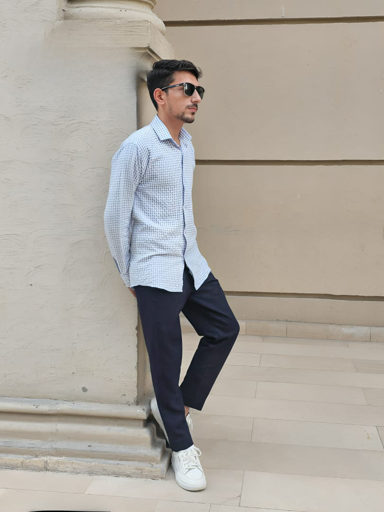


📌 Image saved to: /content/Real-ESRGAN/input/WhatsApp Image 2026-06-30 at 6.07.09 PM.jpeg


In [4]:
# ============================================================
# CELL 8: Upload Image via Google Colab Widget
# ============================================================

from google.colab import files
from pathlib import Path
from PIL import Image
from IPython.display import display, HTML
import shutil, io

ALLOWED_EXTENSIONS = { ".jpg", ".jpeg", ".jfif", ".png", ".bmp", ".webp" }

def upload_image() -> Path:
    """
    Opens a file upload dialog in Colab.
    Validates the file type, saves to INPUT_FOLDER,
    and displays a preview with metadata.

    Returns:
        Path: path to the uploaded image file.
    """
    print("📤 Please upload an image (JPG, JPEG, PNG, BMP, WEBP)...")
    uploaded = files.upload()   # Opens Colab upload dialog

    if not uploaded:
        raise ValueError("❌ No file was uploaded. Please run this cell again.")

    # Grab the first uploaded file
    filename = list(uploaded.keys())[0]
    file_ext = Path(filename).suffix.lower()

    # Validate extension
    if file_ext not in ALLOWED_EXTENSIONS:
        raise ValueError(
            f"❌ Unsupported file type: '{file_ext}'. "
            f"Allowed: {', '.join(ALLOWED_EXTENSIONS)}"
        )

    # Save to input folder
    dest_path = INPUT_FOLDER / filename
    dest_path.write_bytes(uploaded[filename])

    # Open with PIL for metadata
    img = Image.open(dest_path)
    width, height = img.size
    file_size_kb = dest_path.stat().st_size / 1024

    # Display metadata
    print(f"\n{'='*45}")
    print(f"✅ Upload successful!")
    print(f"   Filename   : {filename}")
    print(f"   Dimensions : {width} × {height} px")
    print(f"   Mode       : {img.mode}")
    print(f"   File size  : {file_size_kb:.1f} KB")
    print(f"{'='*45}\n")

    # Show preview (resize for display if large)
    preview = img.copy()
    preview.thumbnail((512, 512))   # Max display size
    display(HTML("<h4>📷 Preview of Uploaded Image:</h4>"))
    display(preview)

    return dest_path

# Run upload
input_image_path = upload_image()
print(f"\n📌 Image saved to: {input_image_path}")

In [5]:
# ============================================================
# CELL 9: Load RealESRGAN_x4plus Model
# ============================================================
# Uses the official RealESRGANer class from the realesrgan package.
# This is the recommended way to load the pretrained model.

from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet
import torch
from pathlib import Path

def load_model(
    model_path: Path = MODEL_PATH,
    scale: int = UPSCALE_FACTOR,
    tile: int = TILE_SIZE,
    tile_pad: int = TILE_PAD,
    pre_pad: int = PRE_PAD,
    half: bool = HALF_PRECISION,
) -> RealESRGANer:
    """
    Loads the official RealESRGAN_x4plus pretrained model.

    Args:
        model_path: Path to the .pth weights file.
        scale:      Upscaling factor (2 or 4).
        tile:       Tile size for large images (0 = disabled).
        tile_pad:   Padding between tiles.
        pre_pad:    Pre-padding size.
        half:       Use FP16 half precision (faster on newer GPUs).

    Returns:
        RealESRGANer: The loaded enhancer object ready for inference.
    """
    if not model_path.exists():
        raise FileNotFoundError(
            f"❌ Model weights not found at: {model_path}\n"
            "   Please run Cell 5 to download the weights."
        )

    # Define the RRDBNet architecture used by RealESRGAN_x4plus
    # These parameters MUST match the pretrained weights exactly.
    model = RRDBNet(
        num_in_ch=3,        # RGB input
        num_out_ch=3,       # RGB output
        num_feat=64,        # Feature channels
        num_block=23,       # RRDB blocks (23 for x4plus)
        num_grow_ch=32,     # Growth channels in dense blocks
        scale=scale,        # Upscaling factor
    )

    # Detect device
    device = torch.device(DEVICE)

    # Create the RealESRGANer wrapper (official inference class)
    upsampler = RealESRGANer(
        scale=scale,
        model_path=str(model_path),
        model=model,
        tile=tile,
        tile_pad=tile_pad,
        pre_pad=pre_pad,
        half=half,
        device=device,
    )

    print("="*50)
    print("✅ Model Loaded Successfully!")
    print(f"   Model     : RealESRGAN_x4plus")
    print(f"   Scale     : {scale}x")
    print(f"   Device    : {device}")
    print(f"   Tile Size : {'Disabled' if tile == 0 else tile}")
    print(f"   Half (FP16): {half}")
    print("="*50)

    return upsampler

# Load the model
upsampler = load_model()

✅ Model Loaded Successfully!
   Model     : RealESRGAN_x4plus
   Scale     : 4x
   Device    : cuda
   Tile Size : Disabled
   Half (FP16): False


In [6]:
# ============================================================
# CELL 10: Image Enhancement Function
# ============================================================
# enhance_image() wraps the official RealESRGANer.enhance() method.

import cv2
import numpy as np
from pathlib import Path

def enhance_image(
    input_path: Path,
    output_path: Path,
    upsampler: "RealESRGANer",
    outscale: float = float(UPSCALE_FACTOR),
) -> Path:
    """
    Enhances a single image using the loaded RealESRGAN model.

    Args:
        input_path:  Path to the input image.
        output_path: Path to save the enhanced image.
        upsampler:   Loaded RealESRGANer instance (from Cell 9).
        outscale:    Final output scale (e.g. 4.0 for 4x).

    Returns:
        Path: path to the saved output image.
    """
    # Read the image using OpenCV (BGR format)
    img = cv2.imread(str(input_path), cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(
            f"❌ Could not read image at: {input_path}\n"
            "   Make sure the file is a valid image."
        )

    # Handle alpha channel (RGBA / BGRA images like PNGs with transparency)
    # Real-ESRGAN can process images with 4 channels too
    if len(img.shape) == 3 and img.shape[2] == 4:
        img_mode = "RGBA"
    else:
        img_mode = "RGB"

    # Run the official Real-ESRGAN enhance() method
    # This handles all preprocessing, inference, and postprocessing internally
    output, _ = upsampler.enhance(img, outscale=outscale)

    # Save the output image
    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), output)

    return output_path

In [7]:
# ============================================================
# CELL 11: Run Inference with Progress Messages
# ============================================================

import time
from pathlib import Path

# Build output filename: original_name + "_enhanced_x4.png"
input_stem   = input_image_path.stem
output_name  = f"{input_stem}_enhanced_x{UPSCALE_FACTOR}.png"
output_path  = OUTPUT_FOLDER / output_name

print("🚀 Starting Enhancement Pipeline...")
print("="*50)

# Step 1: Load image
print("🔄 Step 1/4 — Loading image...")
img_check = Image.open(input_image_path)
orig_w, orig_h = img_check.size
print(f"   Original size: {orig_w} × {orig_h} px")

# Step 2: Enhance
print("\n🔄 Step 2/4 — Enhancing (this may take 30–120 seconds)...")
start_time = time.time()

try:
    result_path = enhance_image(
        input_path=input_image_path,
        output_path=output_path,
        upsampler=upsampler,
        outscale=float(UPSCALE_FACTOR),
    )
except RuntimeError as e:
    if "CUDA out of memory" in str(e):
        print("⚠️  GPU ran out of memory!")
        print("    Solution: Set TILE_SIZE = 400 in Cell 7 and reload model (Cell 9).")
        raise
    else:
        raise

end_time = time.time()
elapsed  = end_time - start_time

# Step 3: Verify output
print("\n🔄 Step 3/4 — Verifying output...")
if not result_path.exists():
    raise FileNotFoundError("❌ Output file was not created. Something went wrong.")

enhanced_img = Image.open(result_path)
enh_w, enh_h = enhanced_img.size
file_size_kb  = result_path.stat().st_size / 1024

print(f"   Enhanced size: {enh_w} × {enh_h} px")
print(f"   File size    : {file_size_kb:.1f} KB")

# Step 4: Done
print("\n✅ Step 4/4 — Completed!")
print("="*50)
print(f"⏱️  Enhancement time : {elapsed:.2f} seconds")
print(f"💾 Output saved to  : {result_path}")

🚀 Starting Enhancement Pipeline...
🔄 Step 1/4 — Loading image...
   Original size: 810 × 1080 px

🔄 Step 2/4 — Enhancing (this may take 30–120 seconds)...

🔄 Step 3/4 — Verifying output...
   Enhanced size: 3240 × 4320 px
   File size    : 13732.1 KB

✅ Step 4/4 — Completed!
⏱️  Enhancement time : 9.83 seconds
💾 Output saved to  : /content/Real-ESRGAN/output/WhatsApp Image 2026-06-30 at 6.07.09 PM_enhanced_x4.png


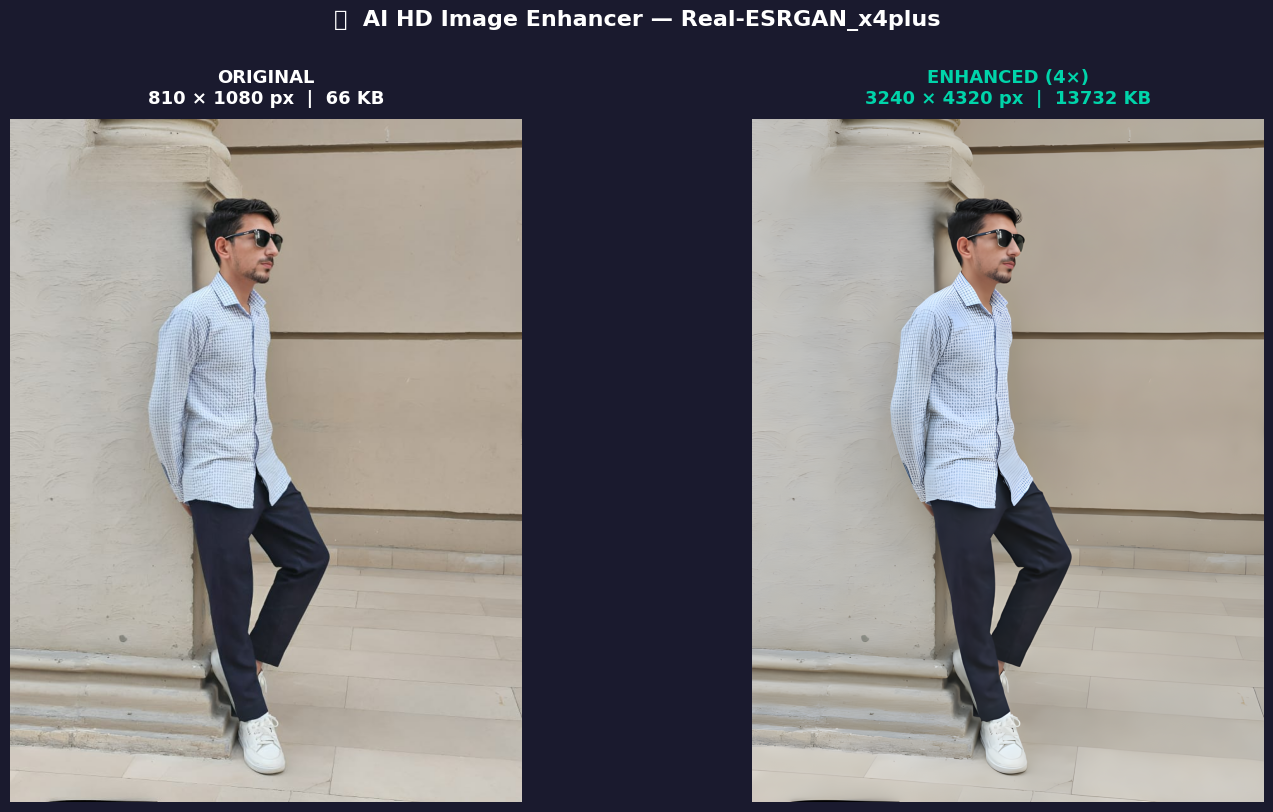

📊 Comparison saved to output/comparison.png

Metric                      Original        Enhanced
----------------------------------------------------
Width (px)                       810           3,240
Height (px)                    1,080           4,320
File Size (KB)                  66.3         13732.1
Scale Factor                      1×              4×


In [8]:
# ============================================================
# CELL 12: Side-by-Side Before / After Comparison
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path

def display_comparison(
    original_path: Path,
    enhanced_path: Path,
) -> None:
    """
    Displays the original and enhanced images side by side
    using matplotlib with metadata annotations.

    Args:
        original_path: Path to original image.
        enhanced_path: Path to enhanced image.
    """
    # Load both images
    orig = Image.open(original_path).convert("RGB")
    enh  = Image.open(enhanced_path).convert("RGB")

    orig_w, orig_h = orig.size
    enh_w,  enh_h  = enh.size
    orig_kb = original_path.stat().st_size / 1024
    enh_kb  = enhanced_path.stat().st_size / 1024

    # Create side-by-side figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.patch.set_facecolor("#1a1a2e")   # Dark background

    # --- Original ---
    axes[0].imshow(orig)
    axes[0].set_title(
        f"ORIGINAL\n{orig_w} × {orig_h} px  |  {orig_kb:.0f} KB",
        color="white", fontsize=13, fontweight="bold", pad=12
    )
    axes[0].axis("off")

    # --- Enhanced ---
    axes[1].imshow(enh)
    axes[1].set_title(
        f"ENHANCED ({UPSCALE_FACTOR}×)\n{enh_w} × {enh_h} px  |  {enh_kb:.0f} KB",
        color="#00d4aa", fontsize=13, fontweight="bold", pad=12
    )
    axes[1].axis("off")

    # Super title
    fig.suptitle(
        "🖼️  AI HD Image Enhancer — Real-ESRGAN_x4plus",
        color="white", fontsize=16, fontweight="bold", y=1.01
    )

    plt.tight_layout()
    plt.savefig(
        str(OUTPUT_FOLDER / "comparison.png"),
        bbox_inches="tight",
        facecolor=fig.get_facecolor(),
        dpi=150,
    )
    plt.show()
    print("📊 Comparison saved to output/comparison.png")

    # Print resolution table
    print(f"\n{'Metric':<20} {'Original':>15} {'Enhanced':>15}")
    print("-" * 52)
    print(f"{'Width (px)':<20} {orig_w:>15,} {enh_w:>15,}")
    print(f"{'Height (px)':<20} {orig_h:>15,} {enh_h:>15,}")
    print(f"{'File Size (KB)':<20} {orig_kb:>15.1f} {enh_kb:>15.1f}")
    print(f"{'Scale Factor':<20} {'1×':>15} {UPSCALE_FACTOR:>14}×")

display_comparison(input_image_path, output_path)

In [9]:
# ============================================================
# CELL 13: Download the Enhanced Image
# ============================================================
# Triggers a browser download using Google Colab's file API.

from google.colab import files
from pathlib import Path
from IPython.display import display, HTML

def download_result(file_path: Path) -> None:
    """
    Downloads the specified file to the user's local machine
    via Google Colab's download mechanism.

    Args:
        file_path: Path to the file to download.
    """
    if not file_path.exists():
        print(f"❌ File not found: {file_path}")
        print("   Please run Cell 11 first to generate the enhanced image.")
        return

    size_kb = file_path.stat().st_size / 1024
    size_mb = size_kb / 1024

    print("="*50)
    print(f"📥 Preparing download...")
    print(f"   File : {file_path.name}")
    print(f"   Size : {size_mb:.2f} MB ({size_kb:.0f} KB)")
    print("="*50)

    files.download(str(file_path))
    print(f"\n✅ Download triggered for: {file_path.name}")
    print("   Check your browser's download folder.")

# Download the enhanced image
download_result(output_path)

# Also offer the comparison image
print("\n📊 Downloading comparison image as well...")
download_result(OUTPUT_FOLDER / "comparison.png")

📥 Preparing download...
   File : WhatsApp Image 2026-06-30 at 6.07.09 PM_enhanced_x4.png
   Size : 13.41 MB (13732 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download triggered for: WhatsApp Image 2026-06-30 at 6.07.09 PM_enhanced_x4.png
   Check your browser's download folder.

📊 Downloading comparison image as well...
📥 Preparing download...
   File : comparison.png
   Size : 1.45 MB (1485 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download triggered for: comparison.png
   Check your browser's download folder.


In [19]:
# ============================================================
# STEP 1: Write app.py — The Gradio HuggingFace Space App
# ============================================================

app_code = '''import spaces  # <--- MUST BE LINE 1 FOR HUGGING FACE ZEROGPU
import gradio as gr
import cv2
import numpy as np
import torch
import os
import time
import tempfile
from pathlib import Path
from PIL import Image
import sys
import torchvision

# Hot-fix for basicsr compatibility with newer torchvision versions
try:
    import torchvision.transforms.functional_tensor
except ImportError:
    import torchvision.transforms.functional as F
    sys.modules['torchvision.transforms.functional_tensor'] = F
from basicsr.archs.rrdbnet_arch import RRDBNet
from realesrgan import RealESRGANer

# ──────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────
MODEL_URL = (
    "https://github.com/xinntao/Real-ESRGAN/releases/download/"
    "v0.1.0/RealESRGAN_x4plus.pth"
)
WEIGHTS_DIR = Path("weights")
MODEL_PATH  = WEIGHTS_DIR / "RealESRGAN_x4plus.pth"
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
MAX_SIZE    = 1500   # Resize input if larger (prevents OOM)

# ──────────────────────────────────────────────
# DOWNLOAD WEIGHTS ON STARTUP
# ──────────────────────────────────────────────
def download_weights():
    WEIGHTS_DIR.mkdir(exist_ok=True)
    if not MODEL_PATH.exists():
        print("Downloading RealESRGAN_x4plus weights...")
        import urllib.request
        urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
        print("Download complete.")
    else:
        print("Weights already present.")

download_weights()

# ──────────────────────────────────────────────
# LOAD MODEL (cached globally)
# ──────────────────────────────────────────────
def load_model():
    model = RRDBNet(
        num_in_ch=3, num_out_ch=3,
        num_feat=64, num_block=23,
        num_grow_ch=32, scale=4,
    )
    upsampler = RealESRGANer(
        scale=4,
        model_path=str(MODEL_PATH),
        model=model,
        tile=400,       # Tile to handle large images without OOM
        tile_pad=10,
        pre_pad=0,
        half=False,
        device=torch.device(DEVICE),
    )
    return upsampler

print(f"Loading model on {DEVICE.upper()}...")
UPSAMPLER = load_model()
print("Model ready!")

# ──────────────────────────────────────────────
# CORE ENHANCE FUNCTION
# ──────────────────────────────────────────────
@spaces.GPU  # <--- Tells Hugging Face to dynamically allocate a GPU for this function
def enhance(image: Image.Image):
    """
    Takes a PIL Image, enhances with Real-ESRGAN x4,
    returns (original_pil, enhanced_pil, stats_str, enhanced_path).
    """
    if image is None:
        return None, None, "Please upload an image first.", None

    start = time.time()

    # Convert PIL → numpy BGR (OpenCV format)
    img_np = cv2.cvtColor(np.array(image.convert("RGB")), cv2.COLOR_RGB2BGR)

    orig_h, orig_w = img_np.shape[:2]

    # Resize if too large to prevent timeout
    if max(orig_h, orig_w) > MAX_SIZE:
        scale_down = MAX_SIZE / max(orig_h, orig_w)
        new_w = int(orig_w * scale_down)
        new_h = int(orig_h * scale_down)
        img_np = cv2.resize(img_np, (new_w, new_h), interpolation=cv2.INTER_AREA)
        resized_note = f" (auto-resized from {orig_w}×{orig_h} to {new_w}×{new_h})"
    else:
        resized_note = ""
        new_w, new_h = orig_w, orig_h

    # Run Real-ESRGAN enhance
    output_bgr, _ = UPSAMPLER.enhance(img_np, outscale=4)

    elapsed = time.time() - start

    # Convert back to PIL RGB
    original_pil  = Image.fromarray(cv2.cvtColor(img_np,     cv2.COLOR_BGR2RGB))
    enhanced_pil  = Image.fromarray(cv2.cvtColor(output_bgr, cv2.COLOR_BGR2RGB))

    enh_w, enh_h = enhanced_pil.size

    stats = (
        f"✅ Enhancement complete in {elapsed:.1f}s\\n"
        f"📐 Original  : {new_w} × {new_h} px{resized_note}\\n"
        f"🔍 Enhanced  : {enh_w} × {enh_h} px (4× upscale)\\n"
        f"🖥️  Device    : {DEVICE.upper()}"
    )

    # Save enhanced image to a temp file for download
    tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    enhanced_pil.save(tmp.name, format="PNG")

    return original_pil, enhanced_pil, stats, tmp.name

# ──────────────────────────────────────────────
# CUSTOM CSS
# ──────────────────────────────────────────────
CSS = """
/* ── Global ── */
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=Space+Grotesk:wght@600;700&display=swap');

body, .gradio-container {
    background: #0d0f14 !important;
    font-family: 'Inter', sans-serif !important;
    color: #e2e8f0 !important;
}

/* ── Header ── */
.app-header {
    text-align: center;
    padding: 2.5rem 1rem 1.5rem;
    border-bottom: 1px solid #1e2330;
    margin-bottom: 2rem;
}
.app-header h1 {
    font-family: 'Space Grotesk', sans-serif;
    font-size: 2.2rem;
    font-weight: 700;
    background: linear-gradient(135deg, #60a5fa 0%, #a78bfa 50%, #f472b6 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    margin: 0 0 0.5rem;
    letter-spacing: -0.5px;
}
.app-header p {
    color: #64748b;
    font-size: 1rem;
    margin: 0;
}
.badge {
    display: inline-block;
    background: #1e2330;
    border: 1px solid #334155;
    color: #94a3b8;
    font-size: 0.75rem;
    padding: 3px 10px;
    border-radius: 20px;
    margin: 0.5rem 4px 0;
    font-weight: 500;
}

/* ── Panels ── */
.panel-label {
    font-size: 0.75rem;
    font-weight: 600;
    letter-spacing: 0.08em;
    text-transform: uppercase;
    color: #475569;
    margin-bottom: 0.4rem;
}

/* ── Upload area ── */
.upload-box {
    border: 2px dashed #2d3748 !important;
    border-radius: 12px !important;
    background: #111827 !important;
    transition: border-color 0.2s !important;
}
.upload-box:hover {
    border-color: #60a5fa !important;
}

/* ── Enhance button ── */
#enhance-btn {
    background: linear-gradient(135deg, #3b82f6, #8b5cf6) !important;
    border: none !important;
    border-radius: 10px !important;
    font-size: 1rem !important;
    font-weight: 600 !important;
    letter-spacing: 0.02em !important;
    color: white !important;
    padding: 14px 0 !important;
    transition: opacity 0.2s, transform 0.1s !important;
    cursor: pointer !important;
}
#enhance-btn:hover {
    opacity: 0.9 !important;
    transform: translateY(-1px) !important;
}
#enhance-btn:active {
    transform: translateY(0) !important;
}

/* ── Download button ── */
#download-btn {
    background: #0f4c2a !important;
    border: 1px solid #22c55e !important;
    border-radius: 10px !important;
    color: #4ade80 !important;
    font-weight: 600 !important;
    font-size: 0.95rem !important;
    transition: background 0.2s !important;
}
#download-btn:hover {
    background: #166534 !important;
}

/* ── Stats box ── */
#stats-box textarea, #stats-box input {
    background: #111827 !important;
    border: 1px solid #1e2330 !important;
    border-radius: 10px !important;
    color: #94a3b8 !important;
    font-size: 0.85rem !important;
    font-family: 'Inter', monospace !important;
    resize: none !important;
}

/* ── Image display ── */
.image-frame img {
    border-radius: 10px !important;
    object-fit: contain !important;
}

/* ── Slider comparison ── */
.image-slider {
    border-radius: 12px !important;
    overflow: hidden !hidden;
}

/* ── Section titles ── */
.section-title {
    font-size: 0.7rem;
    font-weight: 600;
    letter-spacing: 0.1em;
    text-transform: uppercase;
    color: #334155;
    margin: 1.5rem 0 0.75rem;
    display: flex;
    align-items: center;
    gap: 8px;
}
.section-title::after {
    content: '';
    flex: 1;
    height: 1px;
    background: #1e2330;
}

/* ── Footer ── */
.footer {
    text-align: center;
    padding: 1.5rem;
    color: #334155;
    font-size: 0.8rem;
    border-top: 1px solid #1e2330;
    margin-top: 2rem;
}
.footer a { color: #475569; text-decoration: none; }
.footer a:hover { color: #60a5fa; }

/* ── Responsive ── */
@media (max-width: 768px) {
    .app-header h1 { font-size: 1.6rem; }
}
"""

# ──────────────────────────────────────────────
# BUILD GRADIO UI
# ──────────────────────────────────────────────
with gr.Blocks(title="AI HD Image Enhancer — Real-ESRGAN x4plus") as demo:

    # ── Header ──
    gr.HTML("""
    <div class="app-header">
        <h1>🖼️ AI HD Image Enhancer</h1>
        <p>Upscale &amp; restore any photo to 4× HD quality using Real-ESRGAN</p>
        <span class="badge">Real-ESRGAN x4plus</span>
        <span class="badge">4× Upscale</span>
        <span class="badge">CPU / GPU</span>
        <span class="badge">by Maliktg5</span>
    </div>
    """)

    # ── Main layout: left upload | right results ──
    with gr.Row(equal_height=False):

        # ────── LEFT COLUMN — Upload ──────
        with gr.Column(scale=1, min_width=300):
            gr.HTML('<div class="section-title">Upload Image</div>')

            input_image = gr.Image(
                label="",
                type="pil",
                elem_classes=["upload-box"],
                sources=["upload", "clipboard"],
                height=320,
            )

            enhance_btn = gr.Button(
                "✨  Enhance Image (×4)",
                elem_id="enhance-btn",
                size="lg",
            )

            gr.HTML('<div class="section-title">Info</div>')
            stats_box = gr.Textbox(
                label="",
                lines=4,
                interactive=False,
                placeholder="Enhancement stats will appear here...",
                elem_id="stats-box",
            )

        # ────── RIGHT COLUMN — Results ──────
        with gr.Column(scale=2, min_width=400):

            gr.HTML('<div class="section-title">Enhanced Result &amp; Comparison</div>')

            # Slider comparison (before / after)
            comparison_slider = gr.ImageSlider(
                label="",
                type="pil",
                elem_classes=["image-slider"],
                height=420,
                slider_position=0.5,
            )

            gr.HTML('<div class="section-title">Download</div>')

            with gr.Row():
                download_file = gr.File(
                    label="Enhanced Image (PNG)",
                    elem_id="download-btn",
                    interactive=False,
                )

    # ── Examples ──
    gr.HTML('<div class="section-title">Try a Sample</div>')
    gr.Examples(
        examples=[],        # Add sample image paths here if needed
        inputs=input_image,
        label="",
    )

    # ── Footer ──
    gr.HTML("""
    <div class="footer">
        Powered by <a href="https://github.com/xinntao/Real-ESRGAN" target="_blank">Real-ESRGAN</a>
        &nbsp;·&nbsp; Built by <a href="https://huggingface.co/Maliktg5" target="_blank">Maliktg5</a>
        &nbsp;·&nbsp; Hosted on <a href="https://huggingface.co/spaces" target="_blank">Hugging Face Spaces</a>
    </div>
    """)

    # ── Wire up the enhance button ──
    def run_enhance(img):
        orig, enhanced, stats, dl_path = enhance(img)
        if orig is None:
            return None, stats, None
        # ImageSlider takes a tuple of (image1, image2)
        return (orig, enhanced), stats, dl_path

    enhance_btn.click(
        fn=run_enhance,
        inputs=[input_image],
        outputs=[comparison_slider, stats_box, download_file],
    )

# ──────────────────────────────────────────────
# LAUNCH
# ──────────────────────────────────────────────
demo.launch(css=CSS)
'''

# Write app.py to disk
with open("/content/app.py", "w") as f:
    f.write(app_code)

print("✅ app.py rewritten with HuggingFace ZeroGPU support!")

✅ app.py rewritten with HuggingFace ZeroGPU support!


In [20]:
# ============================================================
# STEP 2: Write requirements.txt
# ============================================================

requirements = """torch
torchvision
opencv-python-headless
numpy
Pillow
basicsr
facexlib
gfpgan
realesrgan
gradio>=4.0.0
"""

with open("/content/requirements.txt", "w") as f:
    f.write(requirements)

print("✅ requirements.txt written")
print(requirements)

✅ requirements.txt written
torch
torchvision
opencv-python-headless
numpy
Pillow
basicsr
facexlib
gfpgan
realesrgan
gradio>=4.0.0



In [21]:
# ============================================================
# STEP 3: Push Everything to HuggingFace Space via API
# ============================================================
# 🔐 IMPORTANT:
# Before running this cell:
# 1. Go to Colab left sidebar → click the 🔑 "Secrets" icon
# 2. Add a secret named:  HF_TOKEN
# 3. Paste your HuggingFace token (from hf.co/settings/tokens)
#    Make sure the token has WRITE permissions
# ============================================================

import os
from google.colab import userdata

# ── Get token from Colab Secrets (never hardcode tokens!) ──
try:
    HF_TOKEN = userdata.get("HF_TOKEN")
    print("✅ HF_TOKEN loaded from Colab Secrets")
except Exception:
    raise EnvironmentError(
        "❌ HF_TOKEN not found in Colab Secrets.\n"
        "   Go to: Left sidebar → 🔑 Secrets → Add 'HF_TOKEN'"
    )

# ── Your Space details ──
HF_USERNAME  = "Maliktg5"
SPACE_NAME   = "AI_HD_Image_Enhancer_Real-ESRGAN_x4plus"
REPO_ID      = f"{HF_USERNAME}/{SPACE_NAME}"

print(f"📤 Target Space: https://huggingface.co/spaces/{REPO_ID}")

# ── Install huggingface_hub ──
os.system("pip install -q huggingface_hub")
from huggingface_hub import HfApi, upload_file

api = HfApi()

# ── Verify the Space exists ──
try:
    info = api.repo_info(repo_id=REPO_ID, repo_type="space", token=HF_TOKEN)
    print(f"✅ Space found: {info.id}")
except Exception as e:
    print(f"❌ Could not find Space: {e}")
    print(f"   Make sure the Space '{REPO_ID}' exists on HuggingFace.")
    raise

# ── Upload app.py ──
print("\n📤 Uploading app.py...")
upload_file(
    path_or_fileobj="/content/app.py",
    path_in_repo="app.py",
    repo_id=REPO_ID,
    repo_type="space",
    token=HF_TOKEN,
    commit_message="Update app.py — new UI with slider comparison",
)
print("   ✅ app.py uploaded")

# ── Upload requirements.txt ──
print("📤 Uploading requirements.txt...")
upload_file(
    path_or_fileobj="/content/requirements.txt",
    path_in_repo="requirements.txt",
    repo_id=REPO_ID,
    repo_type="space",
    token=HF_TOKEN,
    commit_message="Update requirements.txt",
)
print("   ✅ requirements.txt uploaded")

print(f"""
{'='*55}
🚀 DEPLOYMENT COMPLETE!
{'='*55}
   Space URL : https://huggingface.co/spaces/{REPO_ID}

   ⏳ HuggingFace will now rebuild your Space.
      This takes ~3–5 minutes on first build.

   📋 To monitor: Visit your Space → click "Logs" tab
{'='*55}
""")

✅ HF_TOKEN loaded from Colab Secrets
📤 Target Space: https://huggingface.co/spaces/Maliktg5/AI_HD_Image_Enhancer_Real-ESRGAN_x4plus
✅ Space found: Maliktg5/AI_HD_Image_Enhancer_Real-ESRGAN_x4plus

📤 Uploading app.py...


No files have been modified since last commit. Skipping to prevent empty commit.


   ✅ app.py uploaded
📤 Uploading requirements.txt...
   ✅ requirements.txt uploaded

🚀 DEPLOYMENT COMPLETE!
   Space URL : https://huggingface.co/spaces/Maliktg5/AI_HD_Image_Enhancer_Real-ESRGAN_x4plus
   
   ⏳ HuggingFace will now rebuild your Space.
      This takes ~3–5 minutes on first build.
      
   📋 To monitor: Visit your Space → click "Logs" tab

